

# Clustering



**Clustering** é uma técnica de aprendizado de máquina **não supervisionado** que tem como objetivo agrupar um conjunto de objetos de tal forma que os objetos no mesmo grupo (ou cluster) sejam mais semelhantes entre si do que com os objetos de outros grupos.

Existem diversos algoritmos de clustering, cada um com suas próprias características e aplicações. Alguns dos algoritmos mais comuns incluem:

- **K-Means**: Um dos algoritmos de clustering mais populares, que particiona os dados em K clusters, onde cada cluster é representado pela média dos pontos dentro dele.
- **Hierarchical Clustering**: Cria uma hierarquia de clusters, que pode ser representada como uma árvore (dendrograma). Pode ser aglomerativo (bottom-up) ou divisivo (top-down).
- **DBSCAN**: Um algoritmo de clustering baseado em densidade que é capaz de encontrar clusters de forma arbitrária e lidar com ruídos.

O clustering é amplamente utilizado em diversas áreas, como segmentação de clientes, análise de redes sociais, reconhecimento de padrões e muito mais. Ele é especialmente útil quando não se tem rótulos ou categorias pré-definidas para os dados, permitindo que os próprios dados revelem suas estruturas subjacentes.

## K-Means

O algoritmo K-Means é um método de clustering que particiona os dados em $K$ clusters, onde cada cluster é representado pela média dos pontos dentro dele (**centroide**).

O algoritmo atribui cada ponto de dados ao cluster mais próximo com base em uma métrica de distância, geralmente a distância euclidiana. O objetivo do K-means é minimizar a soma dos quadrados das distâncias entre os pontos de dados e seus respectivos centroides, o que é conhecido como **within-cluster sum of squares (WCSS)**. Essa técnica é amplamente utilizada em análise de dados, reconhecimento de padrões e processamento de imagens devido à sua simplicidade e eficiência.

![](https://github.com/hsandmann/biblio/blob/main/ml/aula07/kmeans-illustration.png?raw=true)

### Conceitos-chave

- **Clusters**: Grupos de pontos de dados que são semelhantes entre si com base em uma métrica de distância.
- **Aprendizado Não Supervisionado**: O algoritmo funciona sem dados rotulados, identificando padrões apenas com base na estrutura dos dados.
- **Centroides**: São os "centros" dos clusters, representados pela média de todos os pontos em um cluster.
- **K**: O número de clusters, que deve ser especificado antecipadamente (por exemplo, K=3 significa dividir os dados em 3 clusters).
- **Métrica de Distância**: Normalmente, a distância euclidiana é usada para medir quão distante um ponto de dados está de um centróide. O objetivo é atribuir pontos ao centróide mais próximo.
- **Objetivo**: Minimizar a soma dos quadrados das distâncias dentro do cluster (WCSS - Within-Cluster Sum of Squares), que é a soma das distâncias ao quadrado entre cada ponto e seu centróide atribuído. Matematicamente, para um conjunto de dados e centróides, o objetivo é minimizar a função de custo. Exemplo, para o dataset $\textbf{X} = \{x_1, x_2, \dots, x_n\}$ e centroides $\mu=\{ \mu_1, \mu_2, \dots, \mu_n \}$, a função custo é:

    $$ \textbf{WCSS} = \arg \min_{\mu} \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2 $$

    onde $C_i$ é o conjunto de pontos no cluster $i$ e $\mu_i$ é o centróide do cluster $i$.

> K-Means assume que os clusters são esféricos e de tamanho semelhante, o que pode não ser adequado para todos os conjuntos de dados. Além disso, o algoritmo pode ser sensível a outliers e à escolha inicial dos centroides, o que pode levar a resultados subótimos. Para mitigar esses problemas, é comum executar o K-means várias vezes com o mesmo número de $k$ mas com diferentes inicializações e escolher a melhor solução com base na menor WCSS.

### Passo a passo

1. **Inicialização**:

    - Escolha o valor de $K$;
    
    - Aleatoriamento selecione o $K$ inicial do dataset.


2. **Atribuição**:

    - Para cada ponto do dataset, calcule a distância para todos os $k$-centroides;
    
    - Atribua o ponto ao cluster com o centróide mais próximo, com base na métrica de distância escolhida (geralmente a distância euclidiana).


3. **Atualização**:

    - Para cada cluster, recalcule os centroides dos clusters com base nos pontos atribuídos a cada cluster;
    
    - O novo centróide é a média dos pontos de dados em cada cluster.


4. **Iteração**:
    
    - Repita os passos de atribuição (passo 2) e atualização até atingir um dos critérios de parada:
    
        - os centroides não mudem mais (ou a mudança é menor que um limiar - threshold, e.g., 0.001);

        - até atingir um número máximo de iterações (para evitar loops infinitos);
        
        - quando o WCSS cai minimamento entre as iterações.


5. **Saída**:

    - As centroides definidas;

    - As atribuições de cluster para ponto do dataset.

### Exemplo Numérico

Dado um dataset de 2-dimensões (2-features), com 5 exemplos:

$$
\begin{bmatrix}
1 & 2 \\
2 & 1 \\
5 & 8 \\
6 & 7 \\
8 & 6
\end{bmatrix}
$$

Vamos assumir $k = 2$.

- **Inicialização**: aleatoriamente escolhemos os centroides, e.g.: $C_1=(1, 2)$ e $C_2=(5,8)$.

- **Atribuição**:

    - $(1, 2)$ e $(2, 1)$ estão mais próximos de $C_1$ $\implies$ Cluster 1.

    - $(5, 8)$, $(6, 7)$ e $(8, 6)$ estão mais próximos de $C_2$ $\implies$ Cluster 2.

- **Atualização**:

    - $C_1$ = média entre $(1, 2)$ e $(2, 1)$ = $(1.5, 1.5)$;

    - $C_e$ = média entre $(5, 8)$, $(6, 7)$ e $(8, 6)$ = $(6.33, 7)$.

- **Iteração**:

    - Reatribuir os pontos aos novos centroides;

    - Repita os passos de 2 e 3 até uma estabilização.

Para o exemplo, após a convergência, teremos dois clusters, com centroides em $(1.5, 1.5)$ e $(6.33, 7)$.

### Exemplo Ilustrativo

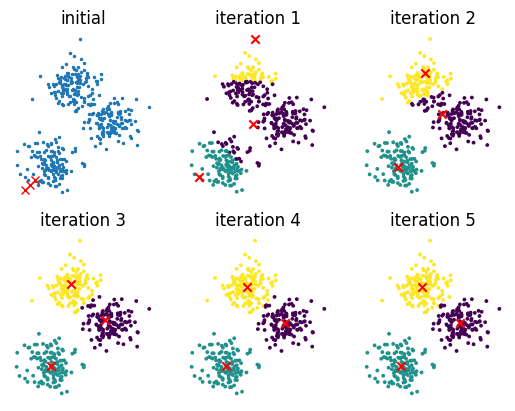

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

fig, axs = plt.subplots(2, 3)

ax = axs[0, 0]
ax.set_title("initial")

X, _ = make_blobs(n_samples=400, centers=3, n_features=2, random_state=42, cluster_std=2.5)
ax.plot(X[:, 0], X[:, 1], '.', ms=3)

initial_centers = np.array([[-10, -10], [-11, -11], [-12, -12]])
ax.plot(initial_centers[:, 0], initial_centers[:, 1], 'xr')
ax.axis('off')

max_it = 5
k = 3
for it in range(1, max_it + 1):
    kmeans = KMeans(
        k,
        n_init=1,
        random_state=42,
        init=initial_centers,
        max_iter=it
    ).fit(X)
    y = kmeans.labels_
    ax = axs[int(it/3), it%3]
    ax.set_title(f'iteration {it}')
    ax.axis('off')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=3)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="red", marker='x')

plt.show()

### Vantagens e Desvantagens

| Aspecto | Vantagens | Desvantagens |
|---|---|---|
| **Simplicidade** | Fácil de entender e implementar; computacionalmente eficiente ($O(n)$ por iteração). | Sensível ao centróide inicial; pode converter para um *ótimo-local*. |
| **Escalabilidade** | Funciona bem com datasets grandes, apresenta complexidade de tempo linear. | Assume que os clusters são esféricos; tem dificuldades com densidades não convexas ou variáveis. |
| **Saída** | Produz agrupamentos compactos e densos; centroides interpretáveis. | Requer um valor K predefinido; valores discrepantes podem distorcer os resultados. |

### Escolhendo $K$

#### **Método do cotovelo** (Elbow Method):

Plote WCSS vs. $K$ e procure por um **cotovelo** onde a taxa de decaimento caí devagar.

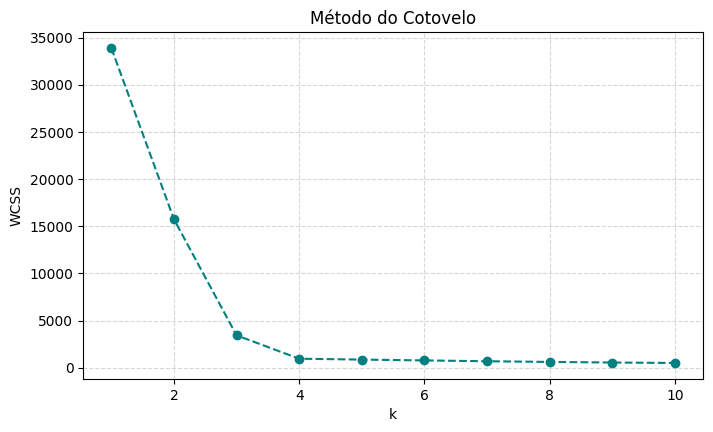

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=500, centers=4, random_state=42)
inertias = [KMeans(k, n_init=10, random_state=42).fit(X).inertia_ for k in range(1,11)]

plt.figure(figsize=(8,4.5))
plt.plot(range(1,11), inertias, 'o--', color='teal')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('Método do Cotovelo')
plt.grid(True, ls='--', alpha=0.5)
plt.show()

#### **Método da Silhueta** (Silhouette Score):

A silhueta mede quão bem cada exemplo está agrupado em relação aos outros clusters.

Ela combina duas ideias:

- **a** = quão próximo o exemplo está dos outros exemplos do mesmo cluster (quanto menor → melhor, cluster compacto);

- **b** = quão distante o exemplo está do cluster mais próximo diferente do seu (quanto maior → melhor, boa separação).

A fórmula do coeficiente de silhueta para um exemplo $i$ é:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Intervalo: $−1 \leq s(i) \leq +1$

| score | significado |
|--:|---|
| $\approx +1$ | exemplo muito bem classificado (muito dentro do seu cluster e longe dos outros) |
| $\approx 0$ | exemplo na fronteira entre dois clusters |
| $ < 0$ | exemplo provavelmente está no cluster errado |



##### **Passo a passo**

Para cada exemplo $i$ no dataset:

- a. Calcule $a(i)$: distância média entre o exemplo $i$ e todos os outros exemplos do mesmo cluster:

    $a(i) = \displaystyle \frac{1}{|C_i| - 1} \sum_{j \in C_i, j \neq i} d(i,j)$

    (onde $C_i$ é número de exemplos do cluster que contém o exemplo $i$, $d$ é a distância — normalmente Euclidiana)
    
- b. Calcule $b(i)$: distância média entre o exemplo $i$ e todos os exemplos do cluster mais próximo diferente do seu.

    Para cada cluster diferente de $C_i$:

    - calcule a distância média de $i$ para todos os pontos daquele cluster;

    - pegue o menor desses valores médios → esse é $b(i)$

        $b(i) = \displaystyle \min_{C_k \neq C_i} \left( \frac{1}{|C_k|} \sum_{j \in C_k} d(i,j) \right)$

Calcule $s(i)$ para cada ponto:

$$s(i) =
\begin{cases}
1 - \frac{a(i)}{b(i)} & \text{se } a(i) < b(i) \\
0 & \text{se } a(i) = b(i) \\
\frac{b(i)}{a(i)} - 1 & \text{se } a(i) > b(i)
\end{cases}$$

Ou, de forma equivalente e mais usada na prática:$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
Silhouette Score médio do modelo (o valor que plotamos no método da silhueta):

$$S = \frac{1}{N} \sum_{i=1}^N s(i)$$

onde $N$ é o número total de exemplos.


##### **Resultado**

| Situação | Interpretação da Silhueta média | Ação sugerida |
|--:|---|---|
| $> 0.7$ | Estrutura muito forte | Excelente agrupamento |
| $(0.5; 0.7]$ | Estrutura razoável | Bom agrupamento |
| $(0.25; 0.5]$ | Estrutura fraca | Talvez aceitável |
| $[0; 0.25]$ | Sem estrutura significativa | Talvez K-Means não seja adequado |
| $<0$ | Muitos pontos mal classificados | Tente outro $k$ ou outro algoritmo |

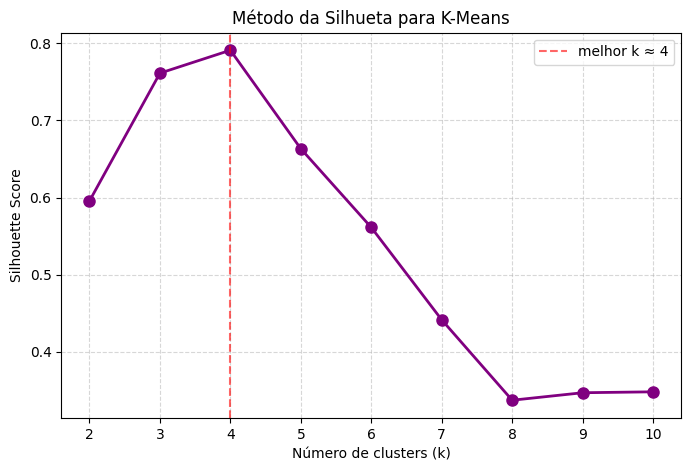

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=4, random_state=42)

scores = [silhouette_score(X, KMeans(k, n_init=10, random_state=42).fit_predict(X))
          for k in range(2, 11)]

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), scores, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método da Silhueta para K-Means')
plt.grid(True, ls='--', alpha=0.5)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='melhor k ≈ 4')
plt.legend()
plt.show()

#### **Comparação**

|Critério|Método do Cotovelo (Elbow)|Método da Silhueta (Silhouette)|Vencedor (na maioria dos casos)|
|---|---|---|---|
| O que mede|Redução da inércia (soma dos quadrados intra-cluster – WCSS)|Qualidade da separação e coesão dos clusters (média do coeficiente de silhueta por ponto)|—|
| Intervalo de valores|Inércia: sempre positiva e decrescente|Silhueta média: -1 a +1|—|
| Facilidade de interpretação| Inspeção visual (procura o "cotovelo")|Mais objetivo: maior valor = melhor k|Silhueta|
| Facilidade de automação|Difícil (o cotovelo nem sempre é claro/obvio)|Fácil (basta pegar o k com maior score)|Silhueta|
| Sensibilidade a ruído / outliers|Moderada (inércia é sensível a pontos distantes)|Alta (pontos mal classificados ou outliers puxam o score para baixo)|Cotovelo (ligeira vantagem)|
| Funciona bem quando clusters têm tamanhos parecidos|Sim|Sim|Empate|
| Funciona bem quando clusters têm tamanhos muito diferentes|Geralmente sim|Pode falhar (clusters pequenos podem ter silhueta baixa mesmo sendo bons)|Cotovelo|
| Funciona bem em clusters com densidades diferentes|Sim|Pode subestimar clusters densos vs. esparsos|Cotovelo|
| Funciona bem em dados de alta dimensionalidade|Razoável|Pode ser enganoso (maldição da dimensionalidade afeta distâncias)|Cotovelo (mais robusto)|
| Custo computacional|Baixo (só calcula inércia)|Médio-alto (precisa calcular distâncias entre todos os pontos e clusters vizinhos)|Cotovelo|
| "Quando o ""melhor k"" é óbvio"|Muito bom (curva clara)|Excelente (score alto e destacado)|Empate|
| Quando não existe cotovelo claro|Fraco (muitas interpretações possíveis)|Melhor (ainda fornece um máximo mensurável)|Silhueta|
| Indica clusters mal formados|Não diretamente|Sim (score médio baixo ou muitos valores negativos)|Silhueta|
| Recomendação geral de uso|"Primeira análise rápida| dados com clusters bem separados e tamanhos semelhantes"|"Análise mais confiável| quando se quer maximizar separação/coesão"|—|

## Exercícios

1. Aplique K-Means ao [Iris Dataset](https://www.kaggle.com/datasets/uciml/iris).

    - Remova os targets;
    - Pré-processe os dados;
    - Obtenha o resultado de clustering e compare com os dados já classificados.

In [14]:
import pandas as pd
df = pd.read_csv('iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
from sklearn.datasets import load_iris
iris = load_iris()
# X: features, y: target labels
X = iris.data
y = iris.target
X.shape, y.shape

((150, 4), (150,))

In [16]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Cria um DataFrame a partir de X (features) e y (target)
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris['target'] = y

# Pré-processamento para clustering:
# Remove a coluna 'target' pois clustering é não supervisionado (sem rótulos)
X_cluster = df_iris.drop(columns=['target'])

# Instancia o scaler para padronizar as features (média 0, desvio padrão 1)
scaler = StandardScaler()

# Ajusta o scaler aos dados e transforma as features (fit + transform em uma etapa)
X_scaled = scaler.fit_transform(X_cluster)

# Converte o array numpy resultante de volta para DataFrame, mantendo os nomes das colunas
X_scaled = pd.DataFrame(X_scaled, columns=X_cluster.columns)

display(X_scaled.head())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


Silhouette Score (qualidade do clustering): 0.4599
Homogeneity Score (pontos do mesmo cluster pertencem à mesma classe): 0.6591
Completeness Score (membros da mesma classe no mesmo cluster): 0.6598
V-Measure Score (média harmônica de homogeneidade e completeness): 0.6595

--- Comparação dos Rótulos Originais vs Preditos ---
    Original  Predito
0          0        1
1          0        1
2          0        1
3          0        1
4          0        1
5          0        1
6          0        1
7          0        1
8          0        1
9          0        1
10         0        1
11         0        1
12         0        1
13         0        1
14         0        1
15         0        1
16         0        1
17         0        1
18         0        1
19         0        1


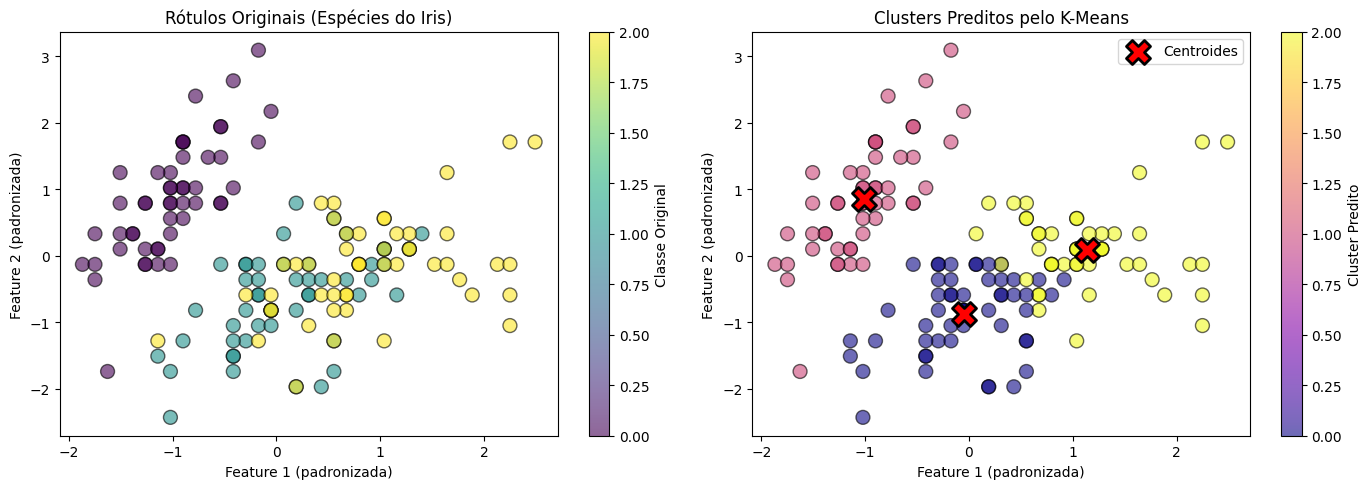


--- Análise de Correspondência ---
Cluster 0: {np.int64(1): np.int64(39), np.int64(2): np.int64(14)}
Cluster 1: {np.int64(0): np.int64(50)}
Cluster 2: {np.int64(1): np.int64(11), np.int64(2): np.int64(36)}


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, v_measure_score
import matplotlib.pyplot as plt
import numpy as np

# Aplicar K-Means com k=3 (3 espécies de Iris)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

# Métricas de avaliação
silhouette_avg = silhouette_score(X_scaled, y_pred)
homogeneity = homogeneity_score(y, y_pred)
completeness = completeness_score(y, y_pred)
v_measure = v_measure_score(y, y_pred)

print(f"Silhouette Score (qualidade do clustering): {silhouette_avg:.4f}")
print(f"Homogeneity Score (pontos do mesmo cluster pertencem à mesma classe): {homogeneity:.4f}")
print(f"Completeness Score (membros da mesma classe no mesmo cluster): {completeness:.4f}")
print(f"V-Measure Score (média harmônica de homogeneidade e completeness): {v_measure:.4f}")

# Comparação dos clusters preditos com os rótulos originais
print("\n--- Comparação dos Rótulos Originais vs Preditos ---")
comparison_df = pd.DataFrame({
    'Original': y,
    'Predito': y_pred
})
print(comparison_df.head(20))

# Visualização: Comparação entre os rótulos reais e preditos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Dados reais com cores dos rótulos originais
scatter1 = axes[0].scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=y, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('Feature 1 (padronizada)')
axes[0].set_ylabel('Feature 2 (padronizada)')
axes[0].set_title('Rótulos Originais (Espécies do Iris)')
plt.colorbar(scatter1, ax=axes[0], label='Classe Original')

# Plot 2: Dados preditos com cores dos clusters
scatter2 = axes[1].scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=y_pred, cmap='plasma', s=100, alpha=0.6, edgecolors='k')
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroides')
axes[1].set_xlabel('Feature 1 (padronizada)')
axes[1].set_ylabel('Feature 2 (padronizada)')
axes[1].set_title('Clusters Preditos pelo K-Means')
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1], label='Cluster Predito')

plt.tight_layout()
plt.show()

# Analisar correspondência entre clusters e classes
print("\n--- Análise de Correspondência ---")
for cluster in range(3):
    mask = y_pred == cluster
    real_labels = y[mask]
    print(f"Cluster {cluster}: {dict(zip(*np.unique(real_labels, return_counts=True)))}")

2. Sobre o exercício anterior, varie o número de $K$, no mínimo $K = \{1, 2, \dots, 10 \}$.

    - Usado o método do cotovelo, plote o gráfico da variação da WCSS;

    - Usado o método da silhueta, plote o gráfico da variação da média da silhueta;

    - Analise os dados sem *bias* de conhecimento prévio dos dados.

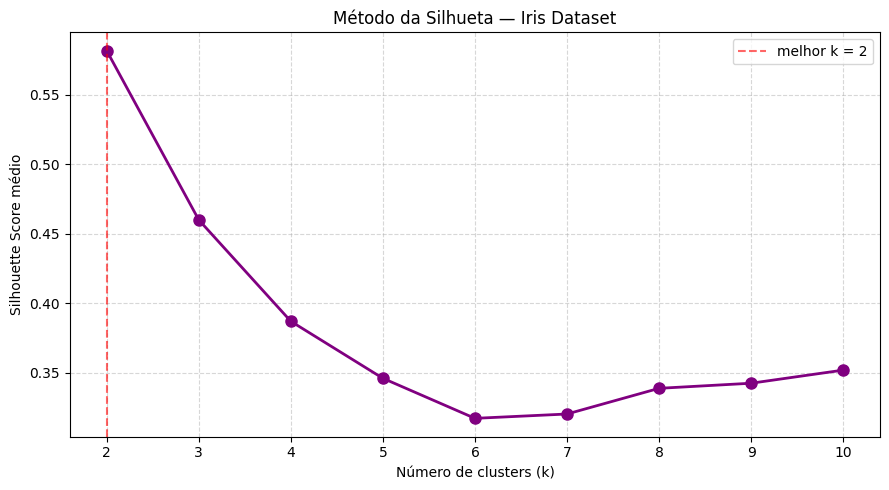


Silhouette Score por k:
  k= 2 → Silhouette = 0.5818 ← melhor
  k= 3 → Silhouette = 0.4599
  k= 4 → Silhouette = 0.3869
  k= 5 → Silhouette = 0.3459
  k= 6 → Silhouette = 0.3171
  k= 7 → Silhouette = 0.3202
  k= 8 → Silhouette = 0.3387
  k= 9 → Silhouette = 0.3424
  k=10 → Silhouette = 0.3518


In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Calcula a silhueta média para cada k de 2 a 10
# (k=1 não tem sentido para silhueta pois não há "outro cluster")
sil_scores = [silhouette_score(X_scaled, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled))
              for k in range(2, 11)]

best_k = range(2, 11)[sil_scores.index(max(sil_scores))]

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), sil_scores, 'o-', color='purple', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'melhor k = {best_k}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score médio')
plt.title('Método da Silhueta — Iris Dataset')
plt.xticks(range(2, 11))
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nSilhouette Score por k:")
for k, s in zip(range(2, 11), sil_scores):
    marker = " ← melhor" if k == best_k else ""
    print(f"  k={k:2d} → Silhouette = {s:.4f}{marker}")

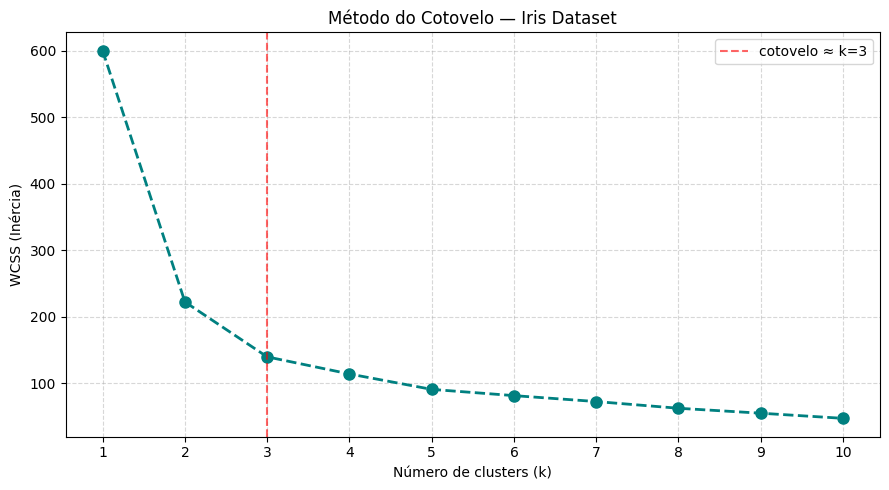


WCSS por k:
  k= 1 → WCSS = 600.0000
  k= 2 → WCSS = 222.3617
  k= 3 → WCSS = 139.8205
  k= 4 → WCSS = 114.0925
  k= 5 → WCSS = 90.9275
  k= 6 → WCSS = 81.5444
  k= 7 → WCSS = 72.6311
  k= 8 → WCSS = 62.5406
  k= 9 → WCSS = 55.1195
  k=10 → WCSS = 47.3910


In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Calcula o WCSS (inércia) para cada k de 1 a 10
wcss = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled).inertia_
        for k in range(1, 11)]

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, 'o--', color='teal', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.title('Método do Cotovelo — Iris Dataset')
plt.xticks(range(1, 11))
plt.grid(True, ls='--', alpha=0.5)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='cotovelo ≈ k=3')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nWCSS por k:")
for k, w in zip(range(1, 11), wcss):
    print(f"  k={k:2d} → WCSS = {w:.4f}")

3. Agora, gerando dados sintéticos $N>=500$, variando $K = \{2, 3, 4, 5, 6, 7\}$, variando as centroides iniciais (no mínimo 3 vezes por configuração), em 2D:

    - aplique K-Means para seguintes configurações de experimentos:

        - 4 classes balanceadas, distribuição em clusters com $\text{std} = 1.2$ (vide [make_blobs](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html));

        - 2 classes balanceadas, distribuição em clusters globulares, com $\text{ruído}=0.05$ (vide [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html)).

        - 4 classes balanceadas, distribuição aleatória.

    - comente erros e acertos de cada experimento;

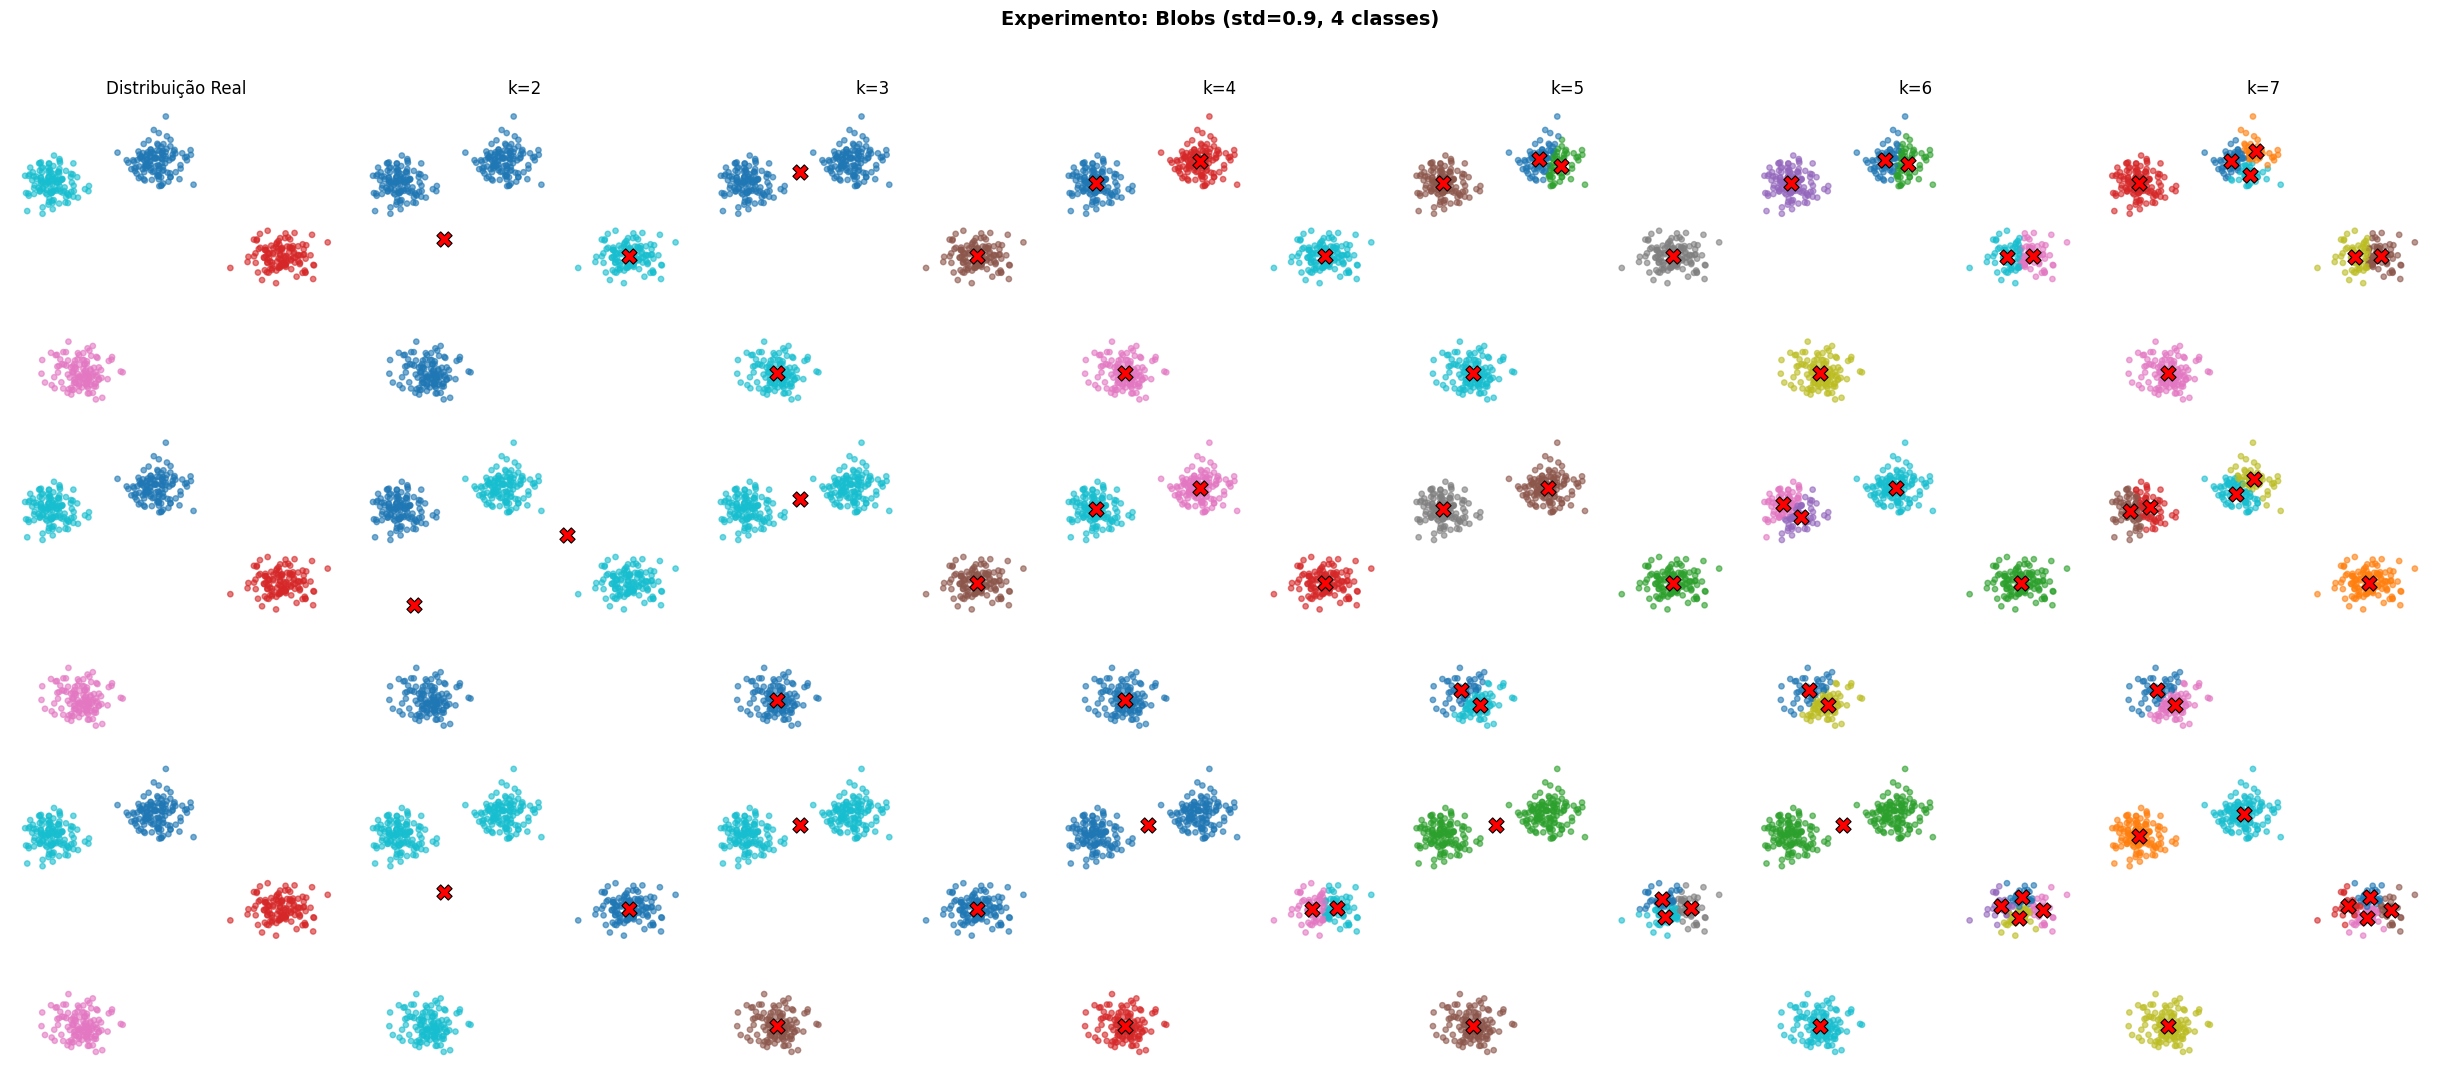

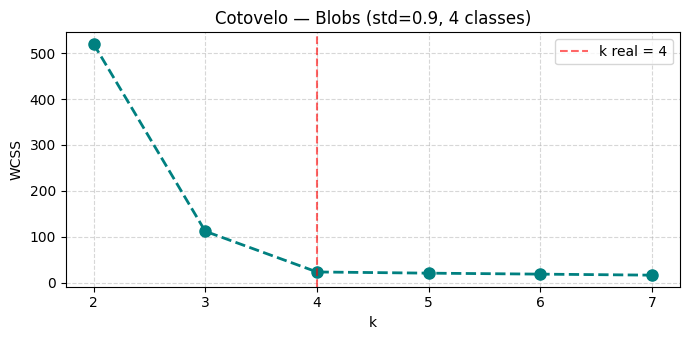

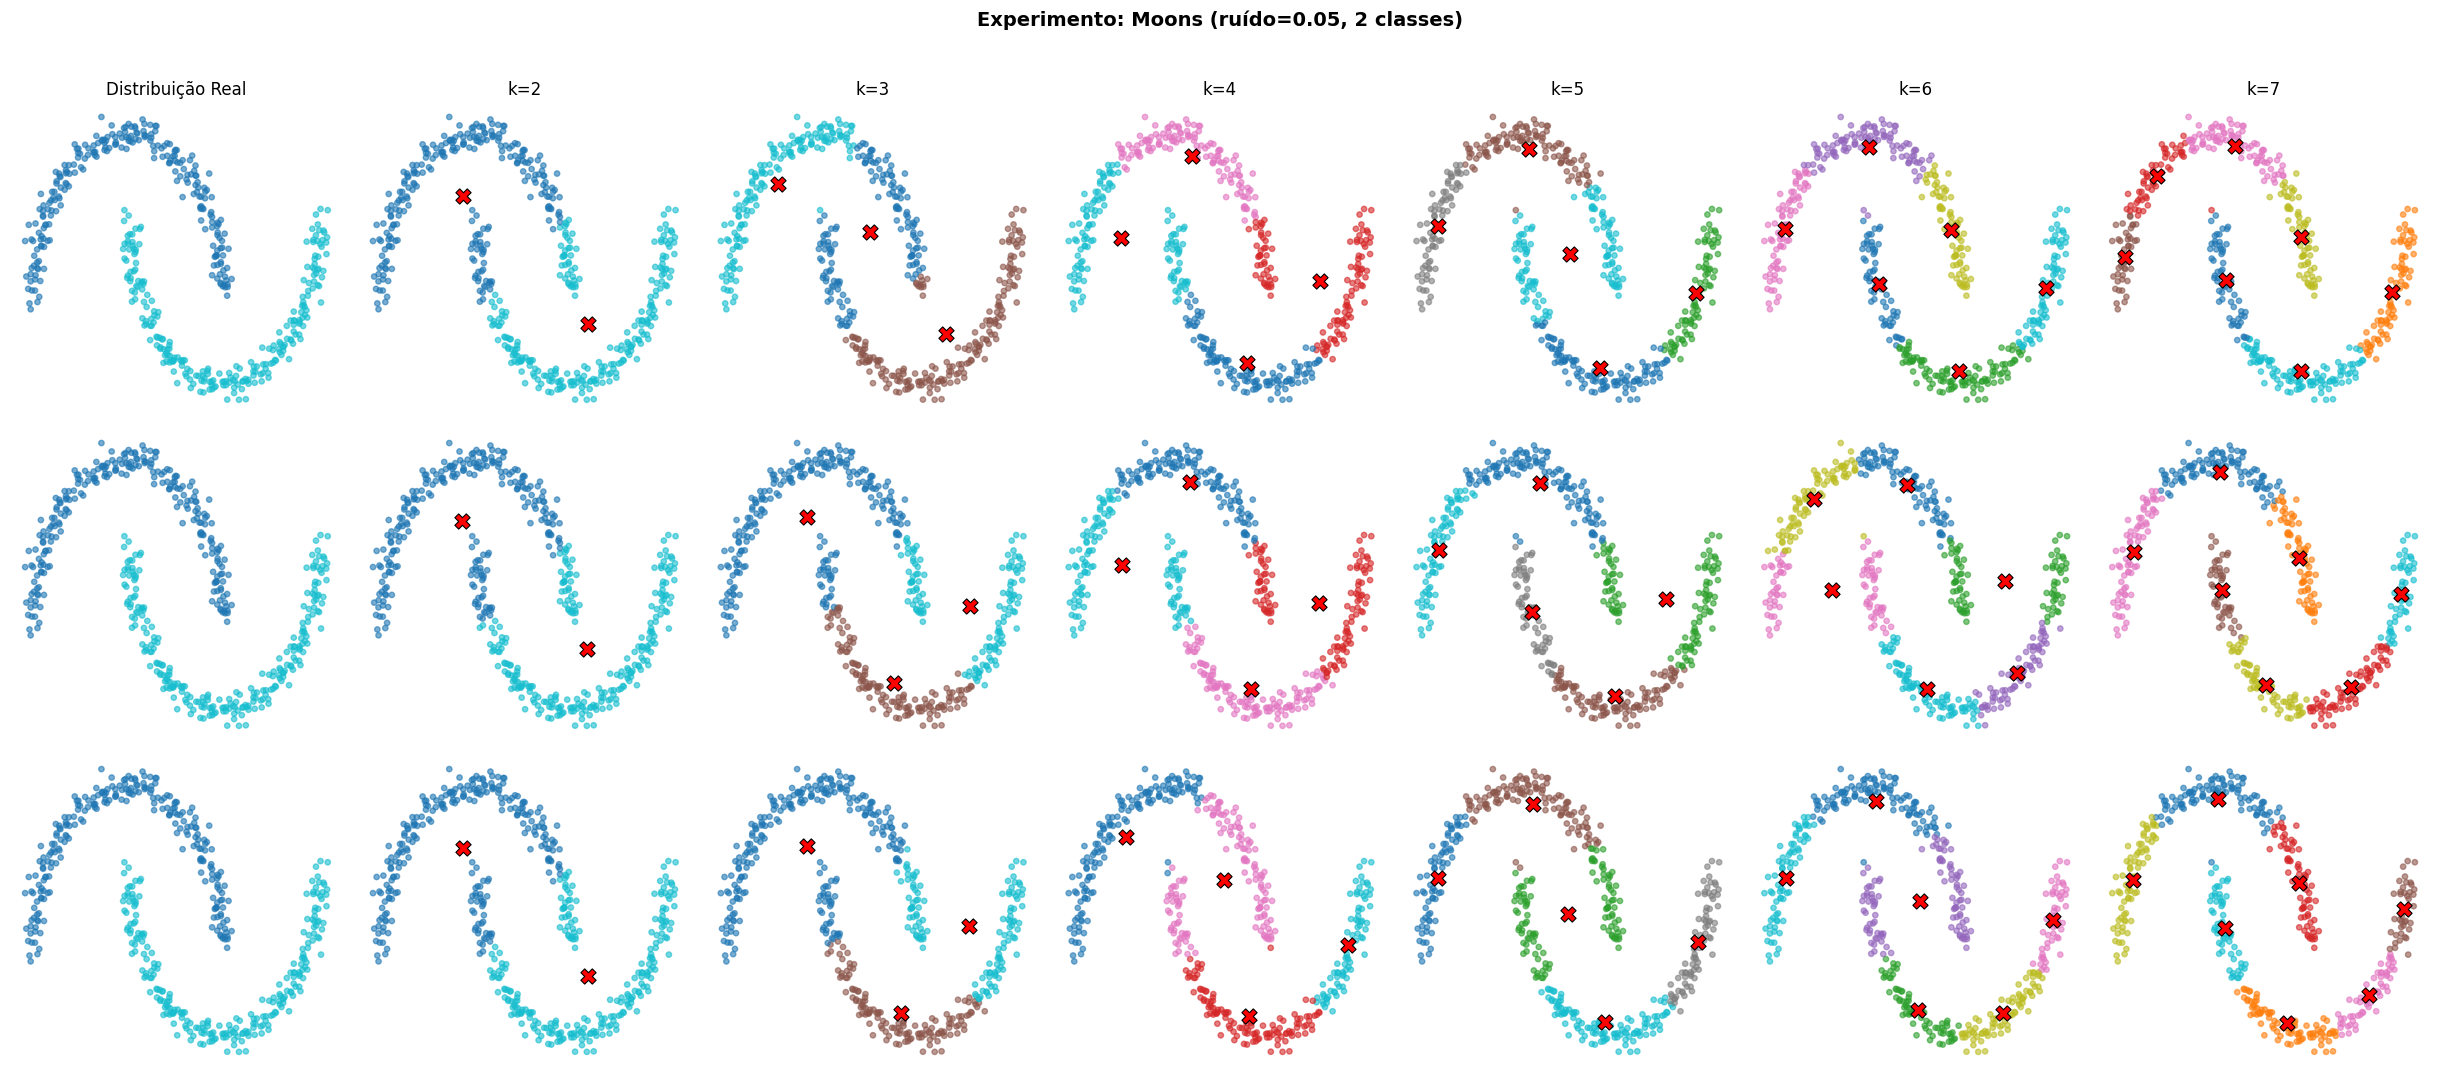

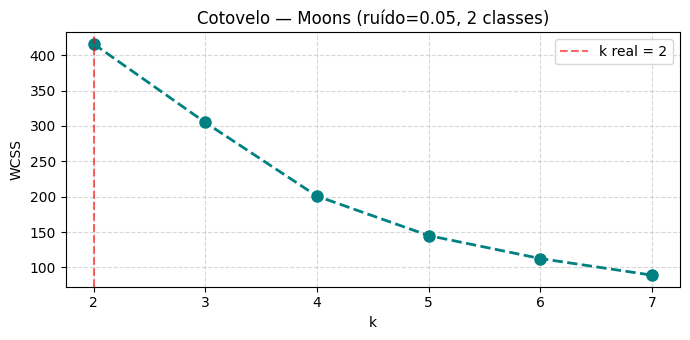

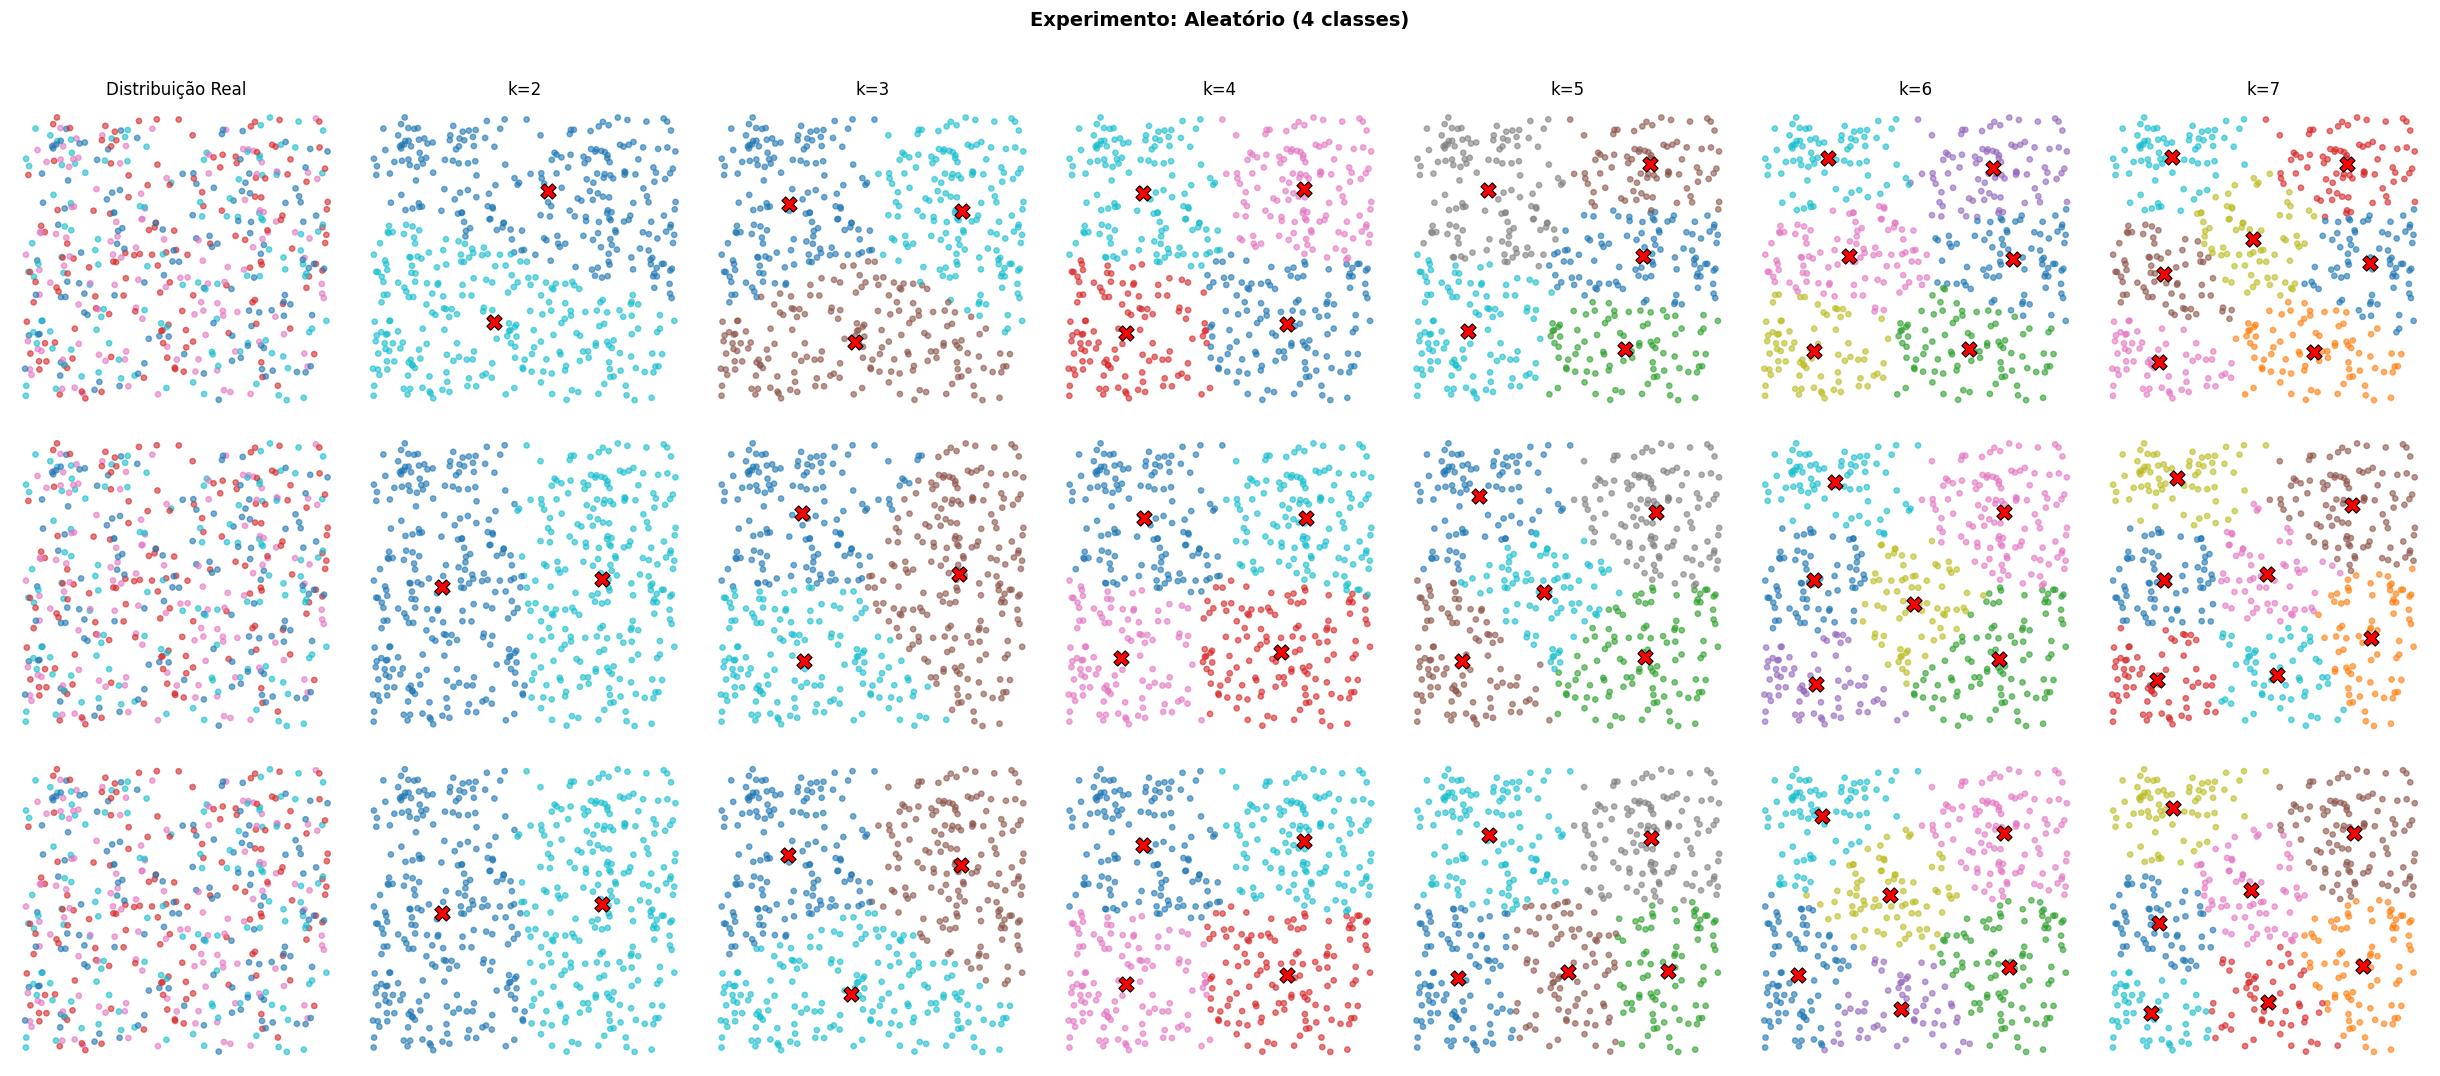

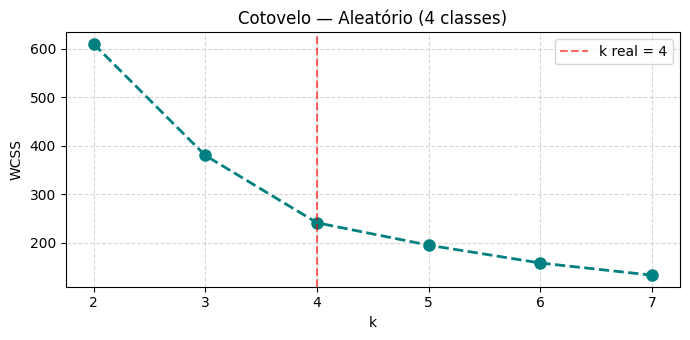


=== ANÁLISE DOS EXPERIMENTOS ===

Experimento 1 — Blobs (std=0.9, 4 classes):
  ✔ ACERTO: K-Means funciona muito bem. Os clusters são esféricos e bem separados,
    exatamente como o algoritmo assume. Com k=4 a segmentação é praticamente perfeita.
  ✔ O cotovelo aparece claramente em k=4, confirmando a estrutura dos dados.
  ✘ Para k < 4 clusters distintos são fundidos; para k > 4 clusters reais são divididos.
  ✘ Sementes diferentes podem gerar rótulos trocados (permutação de clusters), mas
    a estrutura geométrica é preservada.

Experimento 2 — Moons (ruído=0.05, 2 classes):
  ✘ ERRO GRAVE: K-Means falha porque os clusters NÃO são convexos nem esféricos.
    O algoritmo divide cada crescente ao meio, criando clusters esféricos artificiais
    que não correspondem à estrutura real dos dados.
  ✘ Não há um cotovelo claro — a WCSS cai gradualmente sem ponto óbvio.
  → Para este tipo de dado, algoritmos como DBSCAN ou Spectral Clustering são mais adequados.

Experimento 3 — Aleatório 

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────────────────────────────────────
# Configurações dos experimentos
# ─────────────────────────────────────────────────────────────────────────────

N = 500           # número de amostras sintéticas
K_values = [2, 3, 4, 5, 6, 7]   # valores de k a testar
init_seeds = [0, 10, 42]         # 3 sementes diferentes para variar centroides iniciais

# ─────────────────────────────────────────────────────────────────────────────
# Geração dos datasets
# ─────────────────────────────────────────────────────────────────────────────

# Experimento 1: 4 classes balanceadas em clusters esféricos com std=0.9
# make_blobs gera clusters gaussianos — ideal para K-Means
X_blobs, y_blobs = make_blobs(n_samples=N, centers=4, cluster_std=0.9, random_state=42)

# Experimento 2: 2 classes em formato de meia-lua (não convexo) com ruído=0.05
# make_moons cria duas classes em formato de crescente — clusters NÃO esféricos
X_moons, y_moons = make_moons(n_samples=N, noise=0.05, random_state=42)

# Experimento 3: 4 classes com distribuição uniforme/aleatória (sem estrutura clara)
# np.random.uniform gera pontos uniformemente distribuídos no espaço 2D
rng = np.random.default_rng(42)
X_random = rng.uniform(low=-5, high=5, size=(N, 2))
# Atribuímos rótulos aleatórios apenas para referência visual
y_random = rng.integers(0, 4, size=N)

# Agrupamos os experimentos em uma lista para iterar facilmente
experiments = [
    ("Blobs (std=0.9, 4 classes)", X_blobs, y_blobs, 4),
    ("Moons (ruído=0.05, 2 classes)", X_moons, y_moons, 2),
    ("Aleatório (4 classes)", X_random, y_random, 4),
]

# ─────────────────────────────────────────────────────────────────────────────
# Experimentos: para cada dataset, variar K e centroides iniciais
# ─────────────────────────────────────────────────────────────────────────────

for exp_name, X_exp, y_exp, true_k in experiments:

    # Padronizar os dados de cada experimento (média 0, desvio padrão 1)
    # Isso garante que nenhuma feature domine a métrica de distância
    X_exp_scaled = StandardScaler().fit_transform(X_exp)

    # ── Figura principal: distribuição original e clusters para cada K ────────
    n_cols = len(K_values) + 1  # +1 para plotar a distribuição original
    fig, axes = plt.subplots(len(init_seeds), n_cols, figsize=(3.5 * n_cols, 3.5 * len(init_seeds)))
    fig.suptitle(f"Experimento: {exp_name}", fontsize=14, fontweight='bold', y=1.02)

    for row, seed in enumerate(init_seeds):
        # Coluna 0: dados originais (igual para todas as sementes)
        axes[row, 0].scatter(X_exp_scaled[:, 0], X_exp_scaled[:, 1],
                             c=y_exp, cmap='tab10', s=15, alpha=0.6)
        axes[row, 0].set_title("Distribuição Real" if row == 0 else "")
        axes[row, 0].set_ylabel(f"Semente={seed}", fontsize=9)
        axes[row, 0].axis('off')

        for col, k in enumerate(K_values, start=1):
            # Treinar K-Means com semente diferente a cada iteração
            # init='random' força inicialização aleatória pura (sem k-means++)
            km = KMeans(n_clusters=k, init='random', n_init=1, random_state=seed)
            labels = km.fit_predict(X_exp_scaled)

            # Plotar os pontos coloridos pelo cluster predito
            axes[row, col].scatter(X_exp_scaled[:, 0], X_exp_scaled[:, 1],
                                   c=labels, cmap='tab10', s=15, alpha=0.6)
            # Plotar os centroides encontrados
            axes[row, col].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                                   c='red', marker='X', s=120, edgecolors='black', linewidths=0.8)
            axes[row, col].set_title(f"k={k}" if row == 0 else "")
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    # ── Curva WCSS (cotovelo) para este experimento ───────────────────────────
    # Usamos n_init=10 para obter resultado mais estável (média de 10 inicializações)
    wcss_exp = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_exp_scaled).inertia_
                for k in K_values]

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(K_values, wcss_exp, 'o--', color='teal', linewidth=2, markersize=8)
    # Marcar o K verdadeiro como referência
    ax.axvline(x=true_k, color='red', linestyle='--', alpha=0.6, label=f'k real = {true_k}')
    ax.set_xlabel('k')
    ax.set_ylabel('WCSS')
    ax.set_title(f'Cotovelo — {exp_name}')
    ax.set_xticks(K_values)
    ax.grid(True, ls='--', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Comentários sobre erros e acertos de cada experimento
# ─────────────────────────────────────────────────────────────────────────────
print("""
=== ANÁLISE DOS EXPERIMENTOS ===

Experimento 1 — Blobs (std=0.9, 4 classes):
  ✔ ACERTO: K-Means funciona muito bem. Os clusters são esféricos e bem separados,
    exatamente como o algoritmo assume. Com k=4 a segmentação é praticamente perfeita.
  ✔ O cotovelo aparece claramente em k=4, confirmando a estrutura dos dados.
  ✘ Para k < 4 clusters distintos são fundidos; para k > 4 clusters reais são divididos.
  ✘ Sementes diferentes podem gerar rótulos trocados (permutação de clusters), mas
    a estrutura geométrica é preservada.

Experimento 2 — Moons (ruído=0.05, 2 classes):
  ✘ ERRO GRAVE: K-Means falha porque os clusters NÃO são convexos nem esféricos.
    O algoritmo divide cada crescente ao meio, criando clusters esféricos artificiais
    que não correspondem à estrutura real dos dados.
  ✘ Não há um cotovelo claro — a WCSS cai gradualmente sem ponto óbvio.
  → Para este tipo de dado, algoritmos como DBSCAN ou Spectral Clustering são mais adequados.

Experimento 3 — Aleatório (4 classes uniformes):
  ✘ ERRO: Não existe estrutura de clusters nos dados — os pontos são uniformes.
    K-Means força uma partição mesmo sem estrutura subjacente, produzindo clusters
    artificiais dependentes da inicialização (muito sensível à semente).
  ✘ Diferentes sementes produzem resultados muito diferentes — sinal de instabilidade.
  ✘ O cotovelo não é claro; a WCSS cai suavemente sem indicar um k ótimo.
  → K-Means não é adequado para dados sem estrutura de clusters.
""")


4. Pesquise sobre inicialização **K-Means++**.

# Adicional

[![](https://img.youtube.com/vi/njRYKzRKBPY/maxresdefault.jpg)](https://youtu.be/njRYKzRKBPY)

YouTube: [Algoritmo k-means (k-médias)](https://youtu.be/njRYKzRKBPY)